<a href="https://colab.research.google.com/github/VilchisKarla/Procesos-Estocasticos/blob/main/Raton_comida_shock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EJERCICIO**
Vilchis García Karla Ivonne


---


En ausencia de aprendizaje, una rata en un laberinto se mueve aleatoriamente. Si hay k formas de abandonar un laberinto, elije una salida con probabilidad 1/k. ¿Cuál es la probabilidad de que la ratas encuentre primero la comida antes que el electroshock en el siguiente laberinto?

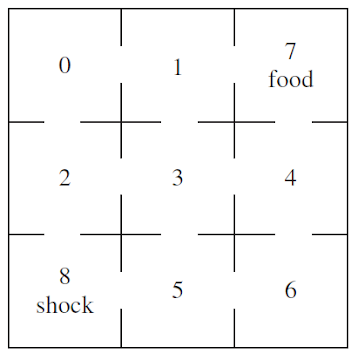

In [2]:
from sympy import Matrix,symbols,solve,pprint,simplify

In [3]:
Laberinto=Matrix([[0,1/2,1/2,0,0,0,0,0,0],[1/3,0,0,1/3,0,0,0,1/3,0],[1/3,0,0,1/3,0,0,0,0,1/3],[0,1/4,1/4,0,1/4,1/4,0,0,0],[0,0,0,1/3,0,0,1/3,1/3,0],[0,0,0,1/3,0,0,1/3,0,1/3],[0,0,0,0,1/2,1/2,0,0,0],[0,0,0,0,0,0,0,1,0],[0,0,0,0,0,0,0,0,1]])
Laberinto.evalf(2)

Matrix([
[   0,  0.5,  0.5,    0,    0,    0,    0,    0,    0],
[0.33,    0,    0, 0.33,    0,    0,    0, 0.33,    0],
[0.33,    0,    0, 0.33,    0,    0,    0,    0, 0.33],
[   0, 0.25, 0.25,    0, 0.25, 0.25,    0,    0,    0],
[   0,    0,    0, 0.33,    0,    0, 0.33, 0.33,    0],
[   0,    0,    0, 0.33,    0,    0, 0.33,    0, 0.33],
[   0,    0,    0,    0,  0.5,  0.5,    0,    0,    0],
[   0,    0,    0,    0,    0,    0,    0,  1.0,    0],
[   0,    0,    0,    0,    0,    0,    0,    0,  1.0]])

## Solucion por ecuaciones de balance

In [6]:
#definimos las probabilidades, donde el estado H es el de la comida (p=1) y el estado I es el del electroshock (p=0)
a, b, c, d, e, f, g = symbols("a b c d e f g")


eq1 = a - (1/2*b + 1/2*c) # de A (0) a B (1) y C (2)
eq2 = b - (1/3*a + 1/3*d + 1/3*1) # de B (1) a A (0), D (3), H (7). p_H = 1
eq3 = c - (1/3*a + 1/3*d + 1/3*0) # de C (2) a A (0), D (3), I (8). p_I = 0
eq4 = d - (1/4*b + 1/4*c + 1/4*e + 1/4*f) # de D (3) a B (1), C (2), E (4), F (5)
eq5 = e - (1/3*d + 1/3*g + 1/3*1) # de E (4) a D (3), G (6), H (7). p_H = 1
eq6 = f - (1/3*d + 1/3*g + 1/3*0) # From F (5) a D (3), G (6), I (8). p_I = 0
eq7 = g - (1/2*e + 1/2*f) # de G (6) a E (4), F (5)

# solucion del sistema
sol = solve((eq1, eq2, eq3, eq4, eq5, eq6, eq7), (a, b, c, d, e, f, g))

#imprimimos la solucion del estado 0
print(f"La probabilidad de que encuentre primero la comida antes que el electroshock, empezando desde el Estado 0 es: {sol[a].evalf(2)}")

La probabilidad de que encuentre primero la comida antes que el electroshock, empezando desde el Estado 0 es: 0.50


## Solucion por simulacion de montecarlo

La probabilidad estimada de llegar primero a la comida es: 0.4998540092810114 




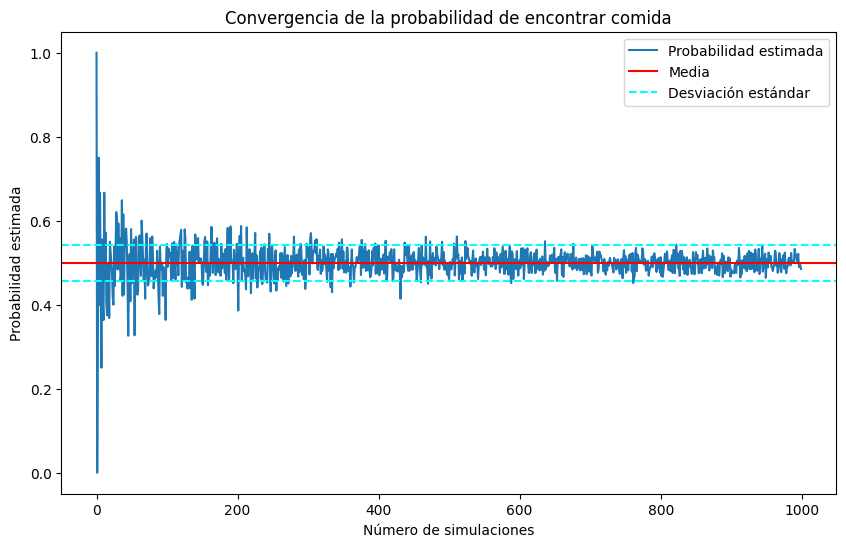

In [5]:
import numpy as np
import random
import matplotlib.pyplot as plt
import math

# Convertir matriz de transición
P_np = np.array(Laberinto).astype(float)

# Estados absorbentes
ELECTROSHOCK = 7
COMIDA = 8
ABSORBENTES = [ELECTROSHOCK, COMIDA]

# Simulación de un camino
def simu_camino(estado_inicial, P):
    estado_actual = estado_inicial
    while estado_actual not in ABSORBENTES:
        proba = P[estado_actual, :]
        estado_siguiente = random.choices(range(len(proba)),weights=proba,k=1)[0]
        estado_actual = estado_siguiente
    return estado_actual

# Experimento Monte Carlo
def experimento(m, estado_inicial, Matriz):
    lista = []
    for i in range(m):
        resultado = simu_camino(estado_inicial, Matriz)
        if resultado == COMIDA:
            lista.append(1)
        else:
            lista.append(0)
    return np.mean(lista)


# Promedios acumulados
def exp(n, estado_inicial, Matriz):
    promedio = []
    for i in range(n):
        promedio.append(experimento(i + 1, estado_inicial, Matriz))
    return promedio


# Ejecutar simulación
estado_inicial = 0
Matriz = P_np

LM = exp(1000, estado_inicial, Matriz)

print(f"La probabilidad estimada de llegar primero a la comida es: {np.mean(LM)} \n\n")

# Graficar
plt.figure(figsize=(10,6))

plt.plot(LM, label="Probabilidad estimada")

plt.axhline(
    y=np.mean(LM),
    color='r',
    label="Media"
)

plt.axhline(
    y=np.mean(LM) + math.sqrt(np.var(LM)),
    color='cyan',
    linestyle='--',
    label="Desviación estándar"
)

plt.axhline(
    y=np.mean(LM) - math.sqrt(np.var(LM)),
    color='cyan',
    linestyle='--'
)

plt.xlabel("Número de simulaciones")
plt.ylabel("Probabilidad estimada")
plt.title("Convergencia de la probabilidad de encontrar comida")

plt.legend()

plt.show()

## Solucion por Matriz fundamental

In [6]:
import sympy as sp
from networkx.classes.function import edges
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import string

In [8]:
def construir_grafo(P):
    n = P.shape[0]
    G = nx.DiGraph()

    for i in range(n):
        for j in range(n):
            if P[i, j] > 0:
                G.add_edge(i,j, weight=P[i, j])  #arcos con su peso

    return G

#función para identificar las clases
def clases_comunicacion(G):
    return list(nx.strongly_connected_components(G))

#función para definir si es clase cerrada
def es_cerrada(P, clase):
    for i in clase:
        for j in range(P.shape[0]):
            if j not in clase and P[i, j] > 0:
                return False
    return True
#función para construir la matriz canónica y separar por bloques transitorios y recurrentes
def reordenar_y_bloques(P):
    G = construir_grafo(P)
    clases = list(nx.strongly_connected_components(G))

    transitorios = []
    recurrentes = []

    # Separar clases
    for c in clases:
        if es_cerrada(P, c):
            recurrentes.append(sorted(list(c)))
        else:
            transitorios.append(sorted(list(c)))

    # Sort transient and recurrent classes based on their first element for consistent ordering
    transitorios.sort(key=lambda x: x[0] if x else -1)  # Handle empty classes if any
    recurrentes.sort(key=lambda x: x[0] if x else -1)

    # Orden final
    orden = []

    for c in transitorios:
        orden.extend(c)

    for c in recurrentes:
        orden.extend(c)

    # Matriz reordenada
    P_new = P[np.ix_(orden, orden)]

    # EXTRAER BLOQUES

    # Tamaño de T
    size_T = sum(len(c) for c in transitorios)

    # Bloque
    if size_T > 0:
        T_block = P_new[:size_T, :size_T]
        print("\nMatriz T (transitoria):\n",'\n\n')
        print(np.array(T_block))
    else:
        print("\nNo hay estados transitorios")

    # Bloques R_i (cada clase recurrente)
    inicio = size_T

    for idx, clase in enumerate(recurrentes):
        size = len(clase)

        R_i = P_new[inicio:inicio+size, inicio:inicio+size]

        print(f"\nMatriz R_{idx+1} (clase {clase}):\n",'\n\n')
        sp.pprint(sp.Matrix(R_i))

        inicio += size

    return P_new, orden, transitorios, recurrentes,T_block

# SOLUCIÓN
P = np.array(Laberinto)

P_new, orden, T, R, Q = reordenar_y_bloques(P)
etiquetas = [f'{i+1}' for i in range(20)]

print("\nClases transientes:", [[etiquetas[s] for s in c] for c in T])
print("Clases recurrentes:", [[etiquetas[s] for s in c] for c in R])
print("\nOrden de estados:", [etiquetas[s] for s in orden])
print("\nMatriz canónica:\n")
print(P_new)
SP=sp.Matrix(P_new)
R = SP.extract([0,1,2,3,4,5,6], [7,8])
print(Q)


Matriz T (transitoria):
 


[[0 0.500000000000000 0.500000000000000 0 0 0 0]
 [0.333333333333333 0 0 0.333333333333333 0 0 0]
 [0.333333333333333 0 0 0.333333333333333 0 0 0]
 [0 0.250000000000000 0.250000000000000 0 0.250000000000000
  0.250000000000000 0]
 [0 0 0 0.333333333333333 0 0 0.333333333333333]
 [0 0 0 0.333333333333333 0 0 0.333333333333333]
 [0 0 0 0 0.500000000000000 0.500000000000000 0]]

Matriz R_1 (clase [7]):
 


[1]

Matriz R_2 (clase [8]):
 


[1]

Clases transientes: [['1', '2', '3', '4', '5', '6', '7']]
Clases recurrentes: [['8'], ['9']]

Orden de estados: ['1', '2', '3', '4', '5', '6', '7', '8', '9']

Matriz canónica:

[[0 0.500000000000000 0.500000000000000 0 0 0 0 0 0]
 [0.333333333333333 0 0 0.333333333333333 0 0 0 0.333333333333333 0]
 [0.333333333333333 0 0 0.333333333333333 0 0 0 0 0.333333333333333]
 [0 0.250000000000000 0.250000000000000 0 0.250000000000000
  0.250000000000000 0 0 0]
 [0 0 0 0.333333333333333 0 0 0.333333333333333 0.333333333333333 0]
 [

In [15]:
I=sp.eye(Q.shape[0])
IQ=I-Q
IQinv=IQ.inv()
IQR=IQinv*R

print('(I-Q)^{-1}*R=F')
sp.pprint(IQR)

(I-Q)^{-1}*R=
⎡       0.5                0.5       ⎤
⎢                                    ⎥
⎢0.666666666666667  0.333333333333333⎥
⎢                                    ⎥
⎢0.333333333333333  0.666666666666667⎥
⎢                                    ⎥
⎢       0.5                0.5       ⎥
⎢                                    ⎥
⎢0.666666666666667  0.333333333333333⎥
⎢                                    ⎥
⎢0.333333333333333  0.666666666666667⎥
⎢                                    ⎥
⎣       0.5                0.5       ⎦



*   La primera columna corresponde al estado 7 (Electroshock).
*   La segunda columna corresponde al estado 8 (Comida).

Si la rata comienza en el estado 0 (la primera fila de la matriz anterior), la probabilidad de que encuentre la comida antes del electroshock es el valor en `F[0, 1]=0.5` (fila 0, columna 1).